In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REPORTS_DIR = BASE_DIR / 'reports'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

print(f"Connected to DB! Data streaming from: {DB_PATH}")

Connected to DB! Data streaming from: D:\Programs\bluestock_mf_capstone\data\db\bluestock_mf.db


In [2]:
query_nav = """
    SELECT amfi_code, nav_date, nav 
    FROM fact_nav 
    ORDER BY amfi_code, nav_date
"""
df_nav = pd.read_sql(query_nav, conn, parse_dates=['nav_date'])

df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

def calc_annualised_return(group):
    returns = group['daily_return'].dropna()
    n_days = len(returns)
    if n_days == 0:
        return np.nan
    compounded = (1 + returns).prod()
    return (compounded ** (252 / n_days)) - 1

df_ann_return = df_nav.groupby('amfi_code').apply(calc_annualised_return).reset_index()
df_ann_return.columns = ['amfi_code', 'annualised_return']

df_nav.to_csv(PROCESSED_DIR / 'returns_computed.csv', index=False)
print("Task 1 Complete: returns_computed.csv saved.")

Task 1 Complete: returns_computed.csv saved.


In [3]:
def compute_cagr(group, periods):
    if len(group) < periods:
        return np.nan 
    
    nav_end = group['nav'].iloc[-1]
    nav_start = group['nav'].iloc[-periods]
    n_years = periods / 252
    
    return ((nav_end / nav_start) ** (1 / n_years)) - 1

cagr_data = []
for amfi_code, group in df_nav.groupby('amfi_code'):
    cagr_data.append({
        'amfi_code': amfi_code,
        'cagr_1yr': compute_cagr(group, 252),
        'cagr_3yr': compute_cagr(group, 756),
        'cagr_5yr': compute_cagr(group, 1260) 
    })

df_cagr = pd.DataFrame(cagr_data)
df_cagr.to_csv(PROCESSED_DIR / 'cagr_report.csv', index=False)
print("Task 2 Complete: cagr_report.csv saved.")

Task 2 Complete: cagr_report.csv saved.


In [4]:
daily_rf = 0.065 / 252

def compute_risk_metrics(group):
    returns = group['daily_return'].dropna()
    if len(returns) == 0:
        return pd.Series({'sharpe_ratio': np.nan, 'sortino_ratio': np.nan})
    
    excess_returns = returns - daily_rf
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
    
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std != 0 else np.nan
    
    return pd.Series({'sharpe_ratio': sharpe, 'sortino_ratio': sortino})

df_risk = df_nav.groupby('amfi_code').apply(compute_risk_metrics).reset_index()
df_risk[['amfi_code', 'sharpe_ratio']].to_csv(PROCESSED_DIR / 'sharpe_values.csv', index=False)
df_risk[['amfi_code', 'sortino_ratio']].to_csv(PROCESSED_DIR / 'sortino_values.csv', index=False)
print("Task 3 & 4 Complete: Risk CSVs saved.")

Task 3 & 4 Complete: Risk CSVs saved.


In [5]:
df_bench = pd.read_csv(RAW_DIR / '10_benchmark_indices.csv', parse_dates=['date'])
df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].sort_values('date')
df_nifty100['bench_return'] = df_nifty100['close_value'].pct_change()
df_nifty100 = df_nifty100.rename(columns={'date': 'nav_date'})[['nav_date', 'bench_return']].dropna()

df_returns_clean = df_nav[['amfi_code', 'nav_date', 'daily_return']].dropna()
df_merged = pd.merge(df_returns_clean, df_nifty100, on='nav_date', how='inner')

alpha_beta_data = []
for amfi_code, group in df_merged.groupby('amfi_code'):
    slope, intercept, r_value, p_value, std_err = stats.linregress(group['bench_return'], group['daily_return'])
    alpha_beta_data.append({
        'amfi_code': str(amfi_code),
        'alpha': intercept * 252, 
        'beta': slope
    })

df_alpha_beta = pd.DataFrame(alpha_beta_data)
df_alpha_beta.to_csv(PROCESSED_DIR / 'alpha_beta.csv', index=False)
print("Task 5 Complete: alpha_beta.csv saved.")

Task 5 Complete: alpha_beta.csv saved.


In [6]:
def compute_max_drawdown(group):
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    return drawdown.min()

df_drawdown = df_nav.groupby('amfi_code').apply(compute_max_drawdown).reset_index()
df_drawdown.columns = ['amfi_code', 'max_drawdown']
df_drawdown.to_csv(PROCESSED_DIR / 'max_drawdown.csv', index=False)
print("Task 6 Complete: max_drawdown.csv saved.")

Task 6 Complete: max_drawdown.csv saved.


In [7]:
df_expense = pd.read_sql("SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund", conn)

for df in [df_cagr, df_risk, df_alpha_beta, df_drawdown, df_expense]:
    df['amfi_code'] = df['amfi_code'].astype(str)

df_scorecard = df_cagr[['amfi_code', 'cagr_3yr']].merge(df_risk, on='amfi_code')
df_scorecard = df_scorecard.merge(df_alpha_beta, on='amfi_code')
df_scorecard = df_scorecard.merge(df_drawdown, on='amfi_code')
df_scorecard = df_scorecard.merge(df_expense, on='amfi_code')

df_scorecard = df_scorecard.dropna(subset=['cagr_3yr'])

rank_3yr = df_scorecard['cagr_3yr'].rank(pct=True) * 100
rank_sharpe = df_scorecard['sharpe_ratio'].rank(pct=True) * 100
rank_alpha = df_scorecard['alpha'].rank(pct=True) * 100
rank_expense = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) * 100
rank_dd = df_scorecard['max_drawdown'].rank(pct=True, ascending=True) * 100

df_scorecard['composite_score'] = (
    (0.30 * rank_3yr) + 
    (0.25 * rank_sharpe) + 
    (0.20 * rank_alpha) + 
    (0.15 * rank_expense) + 
    (0.10 * rank_dd)
).round(2)

df_scorecard = df_scorecard.sort_values('composite_score', ascending=False)
df_scorecard.to_csv(PROCESSED_DIR / 'fund_scorecard.csv', index=False)
print("Task 7 Complete: fund_scorecard.csv saved.")

Task 7 Complete: fund_scorecard.csv saved.


Executing Task 8: Benchmark Comparison Chart...
Task 8 Complete: benchmark_chart.png saved.


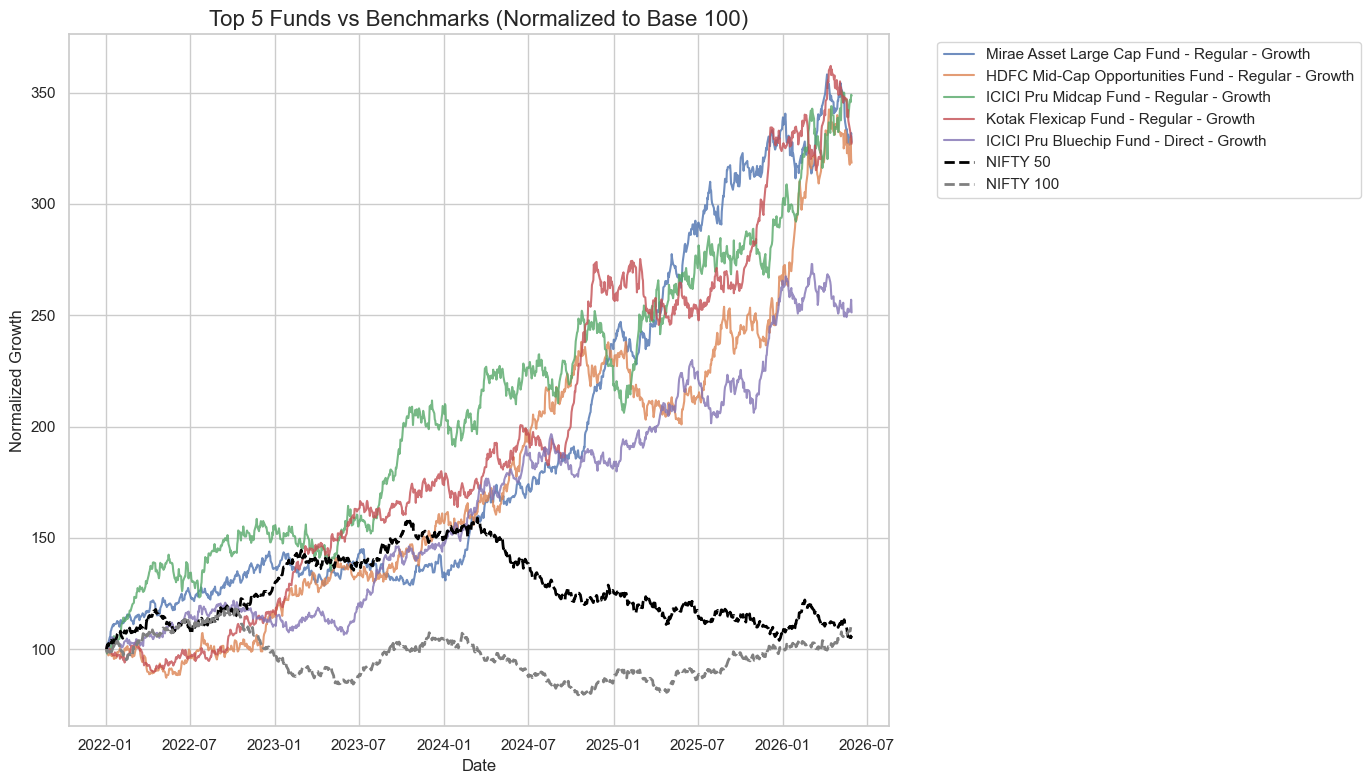

In [8]:
print("Executing Task 8: Benchmark Comparison Chart...")

df_nav['amfi_code'] = df_nav['amfi_code'].astype(str) 

top_5_amfi = df_scorecard.head(5)['amfi_code'].tolist()
top_5_names = df_scorecard.head(5)['scheme_name'].tolist()

df_nav_top5 = df_nav[df_nav['amfi_code'].isin(top_5_amfi)]

df_nifty50 = df_bench[df_bench['index_name'] == 'NIFTY50'].rename(columns={'date': 'nav_date', 'close_value': 'NIFTY 50'})
df_nifty100_bench = df_bench[df_bench['index_name'] == 'NIFTY100'].rename(columns={'date': 'nav_date', 'close_value': 'NIFTY 100'})

plt.figure(figsize=(14, 8))

# Normalize data to base 100 for visual comparison
for amfi, name in zip(top_5_amfi, top_5_names):
    fund_data = df_nav_top5[df_nav_top5['amfi_code'] == amfi].sort_values('nav_date')
    if not fund_data.empty:
        normalized_nav = (fund_data['nav'] / fund_data['nav'].iloc[0]) * 100
        plt.plot(fund_data['nav_date'], normalized_nav, label=name, alpha=0.8)

for bench_df, label, color in zip([df_nifty50, df_nifty100_bench], ['NIFTY 50', 'NIFTY 100'], ['black', 'grey']):
    bench_df = bench_df.sort_values('nav_date')
    if not bench_df.empty:
        normalized_bench = (bench_df[label] / bench_df[label].iloc[0]) * 100
        plt.plot(bench_df['nav_date'], normalized_bench, label=label, color=color, linewidth=2, linestyle='--')

plt.title('Top 5 Funds vs Benchmarks (Normalized to Base 100)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalized Growth')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'benchmark_chart.png')
print("Task 8 Complete: benchmark_chart.png saved.")

conn.close()